In [1]:
import os
def search_wavs(rootdir):
    paths=[]
    for root, dirs, files in os.walk(rootdir):
        for file in files:
            if file.endswith(".wav"):
                paths.append(os.path.join(root,file))               
    
    return paths

def get_oraclepath(path,oracledir='mos/oracle'):
    name=path.split('/')[-1]
    info=name.split('_')
    sourcespk=info[0]
    utt=info[-1][:3]
    return f'{oracledir}/{sourcespk}/{sourcespk}_{utt}.wav'

def get_tgtoracle(path,oracledir='mos/oracle', mode='corre'):
    name=path.split('/')[-1]
    info=name.split('_')
    tgtspk=info[1]
    if mode=='corre':
        utt=info[-1][:3]
    else:
        utt='001'
    return f'{oracledir}/{tgtspk}/{tgtspk}_{utt}.wav'

get_tgtoracle('mos/outputs_diffvc/p238/p238_p241_001.wav'),get_oraclepath('mos/oracle/p238/p238_001.wav')

('mos/oracle/p241/p241_001.wav', 'mos/oracle/p238/p238_001.wav')

In [2]:
import numpy as np
def cosine_similarity(vector1, vector2):
    dot_product = np.dot(vector1, vector2)
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)
    
    similarity = dot_product / (norm_vector1 * norm_vector2)
    
    return similarity

In [3]:
import sys
sys.path.append('./speaker_encoder/')
from encoder import inference as spk_encoder
def get_embed(wav_path):
    wav_preprocessed = spk_encoder.preprocess_wav(wav_path)
    embed = spk_encoder.embed_utterance(wav_preprocessed)
    return embed

In [4]:
from pathlib import Path
enc_model_fpath = Path('./checkpts/spk_encoder/pretrained.pt') # speaker encoder path
spk_encoder.load_model(enc_model_fpath, device="cuda")
get_embed('./example/6415_111615_000012_000005.wav').shape

Loaded encoder "pretrained.pt" trained to step 1564501


(256,)

In [4]:
import torchcrepe

In [6]:
audio,sr0 = torchcrepe.load.audio('mos/oracle/p238/p238_001.wav')
sr0,audio.shape

(22050, torch.Size([1, 68608]))

In [5]:
import numpy as np

def normalize_curve(y_values):  
    min_value = y_values.min()
    max_value = y_values.max()
    normalized_curve = (y_values - min_value) / (max_value - min_value)
    return normalized_curve

In [17]:
import librosa
import torch

fmin = 50
fmax = 550
model = 'tiny' # "tiny" or "full"
device = 'cuda:0'
batch_size = 2048

def get_f0(path,normalize=True):
    wav, sr = librosa.load(path,sr=22050)
    hop_length = int(sr/200.)
    pitch = torchcrepe.predict(torch.from_numpy(wav).unsqueeze(0).cuda(),
                            sr,
                            hop_length,
                            fmin,
                            fmax,
                            model,
                            batch_size=batch_size,
                            device=device).detach().cpu().squeeze().numpy()
    if normalize:
        return normalize_curve(pitch)
    else: 
        return pitch

In [7]:
get_f0('mos/oracle/p238/p238_001.wav').shape

(631,)

In [2]:
import matplotlib.pyplot as plt
def plot_curve(y_values,figsize=(10,2)):
    x_values = range(len(y_values))
    plt.figure(figsize=figsize) 
    plt.plot(x_values, y_values, label='Curve') 
    plt.xlabel('time')
    plt.ylabel('f0')
    plt.title('Curve Plot')
    plt.show()

In [45]:
lstm1=torch.nn.LSTM(1,256,2,batch_first=True, bidirectional=True)

In [43]:
curve=torch.from_numpy(get_f0('example/0001_000001.wav',normalize=False)/100).unsqueeze(1)
curve.shape

torch.Size([836, 1])

In [46]:
lstm1(curve)[0].shape

torch.Size([836, 512])

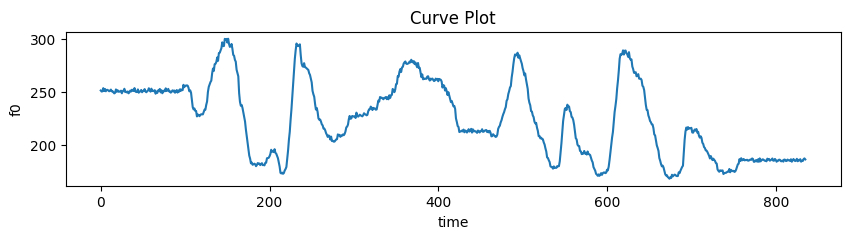

In [18]:
plot_curve(get_f0('example/0001_000001.wav',normalize=False))

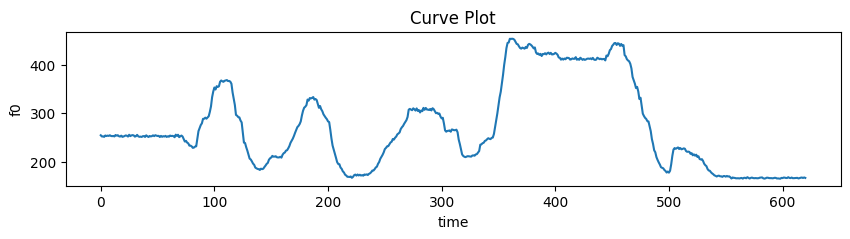

In [19]:
plot_curve(get_f0('example/0001_000351.wav',normalize=False))

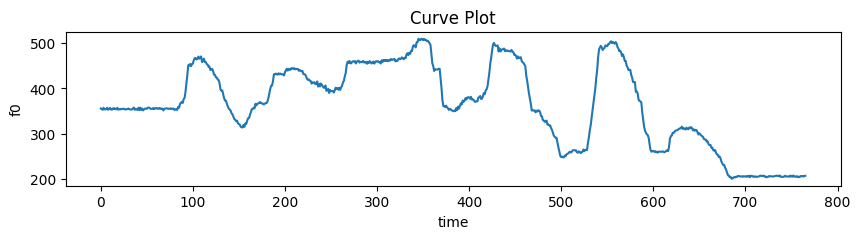

In [20]:
plot_curve(get_f0('dataset/ESD/wavs/0001/0001_000701.wav',normalize=False))

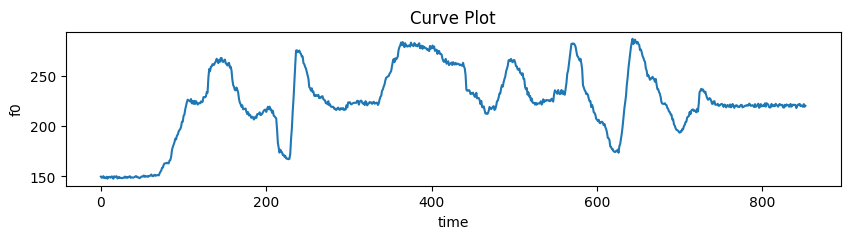

In [21]:
plot_curve(get_f0('dataset/ESD/wavs/0001/0001_001051.wav',normalize=False))

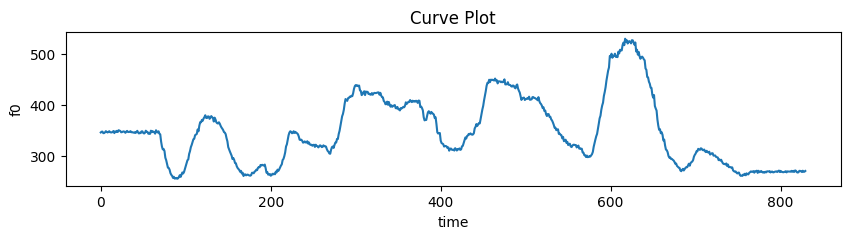

In [22]:
plot_curve(get_f0('dataset/ESD/wavs/0001/0001_001401.wav',normalize=False))

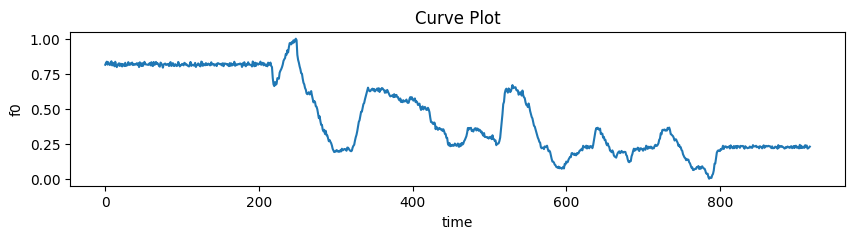

In [20]:
p0=get_f0('mos/oracle/p238/p238_002.wav')
plot_curve(p0)

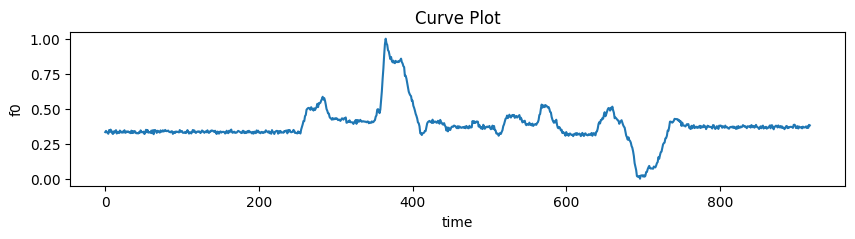

In [21]:
p1=get_f0('mos/outputs_diffvc/p238/p238_p241_002.wav')
plot_curve(p1)

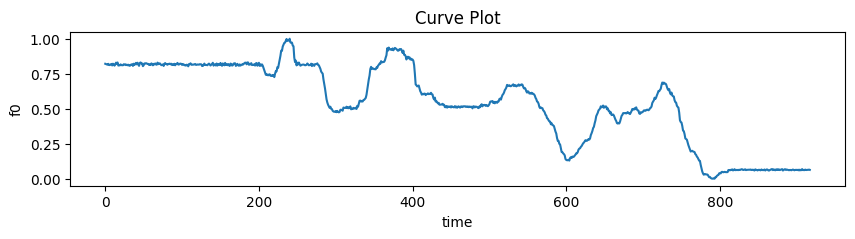

In [22]:
p2=get_f0('mos/outputs_diffvcplus/p238/p238_p241_002.wav')
plot_curve(p2)

In [23]:
np.corrcoef(p0,p1)[0, 1], np.corrcoef(p1,p0)[0, 1]

(0.05179340998735162, 0.05179340998735162)

In [44]:
np.corrcoef(p0,p2)[0, 1]

0.8399335233510336

In [6]:
def mae(y_values1, y_values2):

    if len(y_values1) != len(y_values2):
        raise ValueError("y 值序列长度不匹配")
    
    errors = np.abs(y_values1 - y_values2)
    mae = np.mean(errors)

    return mae


In [72]:
mae(p0,p1),mae(p0,p2),mae(p0,p1)*len(p0),mae(p0,p2)*len(p0)

(0.24946722, 0.14223053, 229.0109115242958, 130.56762251257896)

In [12]:
def get_mae(path):
    oracle=get_oraclepath(path)
    p0=get_f0(oracle)
    p=get_f0(path)
    return mae(p,p0)

In [9]:
import numpy as np
def get_pc(path):
    oracle=get_oraclepath(path)
    p0=get_f0(oracle)
    p=get_f0(path)
    return np.corrcoef(p0,p)[0, 1]

In [75]:
get_mae('mos/outputs_diffvc/p238/p238_p241_002.wav'),get_mae('mos/outputs_diffvcplus/p238/p238_p241_002.wav')

(0.24838258, 0.1446785)

In [13]:
get_pc('mos/outputs_diffvc/p238/p238_p241_002.wav'),get_pc('mos/outputs_diffvcplus/p238/p238_p241_002.wav')

(0.04818867052277405, 0.8402878095651248)

In [62]:
from fastdtw import fastdtw

In [74]:
distance1, path = fastdtw(p0, p1)
distance2, path = fastdtw(p0, p2)
distance1,distance2

(193.6666968248319, 73.63700941985007)

In [68]:
pp0 = np.column_stack((np.arange(len(p0)), p0))
pp1 = np.column_stack((np.arange(len(p1)), p1))
pp2 = np.column_stack((np.arange(len(p2)), p2))

In [69]:
distance1, path = fastdtw(pp0, pp1)
distance2, path = fastdtw(pp0, pp2)
distance1, distance2  

(229.01090139127336, 130.56762774696108)

In [80]:
from scipy.spatial.distance import euclidean
distance, path = fastdtw(pp0, pp1, dist=None)
print(distance)

229.01090139127336


In [8]:
from tqdm import tqdm
def batch_mae(dir):
    maes=[]
    for wav in tqdm(search_wavs(dir)):
        mae=get_mae(wav)
        maes.append(mae)
    return np.mean(maes)

In [10]:
from tqdm import tqdm
def batch_pc(dir):
    pcs=[]
    for wav in tqdm(search_wavs(dir)):
        pc=get_pc(wav)
        pcs.append(pc)
    return np.mean(pcs)

In [88]:
batch_mae('mos/oracle')

100%|██████████| 50/50 [01:36<00:00,  1.93s/it]


0.009342566

In [90]:
batch_mae('mos/outputs_diffvc')

100%|██████████| 450/450 [14:40<00:00,  1.96s/it]


0.29054734

In [91]:
batch_mae('mos/outputs_diffvcplus')

100%|██████████| 450/450 [14:40<00:00,  1.96s/it]


0.17640813

In [138]:
batch_mae('./outputs_diffvcplus')

100%|██████████| 450/450 [15:10<00:00,  2.02s/it]


0.17026988

In [137]:
batch_mae('mos/outputs_diffvcp_light')

100%|██████████| 450/450 [08:41<00:00,  1.16s/it]


0.16397966

In [136]:
batch_mae('mos/outputs_diffvcp_ctrl')

100%|██████████| 450/450 [15:00<00:00,  2.00s/it]


0.16764064

In [9]:
batch_mae('./outputs_diffvcp_light_streaming')

100%|██████████| 450/450 [15:02<00:00,  2.01s/it]


0.18709627

In [ ]:
#####

In [163]:
batch_mae('./outputs_diffvcp'), batch_mae('./outputs_diffvcpl')

100%|██████████| 50/50 [01:37<00:00,  1.95s/it]


(0.18843101, 0.15550311)

In [164]:
batch_mae('./outputs_diffvcpd'), batch_mae('./outputs_diffvcpd_uc')

100%|██████████| 50/50 [01:38<00:00,  1.97s/it]


(0.17243247, 0.1896447)

In [26]:
batch_mae('mos/outputs_diffvc_official')

100%|██████████| 450/450 [14:17<00:00,  1.91s/it]


0.26492757

: 

In [ ]:
###

In [16]:
batch_pc('mos/oracle')

100%|██████████| 50/50 [02:01<00:00,  2.43s/it]


0.9991769165517645

In [17]:
batch_pc('mos/outputs_diffvc'), batch_pc('mos/outputs_diffvcplus'), batch_pc('mos/outputs_diffvcp_light'),batch_pc('mos/outputs_diffvcp_ctrl')

100%|██████████| 450/450 [14:42<00:00,  1.96s/it]


(0.2566421375603231,
 0.6911535830327042,
 0.7326444650182066,
 0.7202728287139765)

In [19]:
batch_pc('./outputs_diffvcp_light_streaming'), batch_pc('mos/outputs_diffvc_official/')

100%|██████████| 450/450 [15:06<00:00,  2.01s/it]


(0.6562191287591917, 0.3445599456487007)

In [18]:
batch_pc('./outputs_diffvcp'), batch_pc('./outputs_diffvcpl'), batch_pc('./outputs_diffvcpd'), batch_pc('./outputs_diffvcpd_uc')

100%|██████████| 50/50 [01:37<00:00,  1.96s/it]


(0.6479804777696991,
 0.7605755535178492,
 0.6829402361019216,
 0.6587186256653956)

In [13]:
batch_pc('./outputs_test')

100%|██████████| 450/450 [21:16<00:00,  2.84s/it]


0.7300074178259754

In [11]:
batch_pc('./outputs_eg'), batch_pc('./outputs_uc')

100%|██████████| 50/50 [02:11<00:00,  2.62s/it]


(0.6729611664608792, 0.6011732757004291)

In [12]:
def get_sim(path):
    tgtoracle=get_tgtoracle(path,mode=None)
    emb1=get_embed(path)
    emb2=get_embed(tgtoracle)
    return cosine_similarity(emb1,emb2)

get_sim('mos/outputs_diffvcplus/p238/p238_p241_002.wav'),get_sim('mos/outputs_diffvc/p238/p238_p241_002.wav')

(0.7270926, 0.7855665)

In [13]:
def get_dist(path):
    oracle=get_oraclepath(path)
    emb1=get_embed(path)
    emb2=get_embed(oracle)
    return 1 - cosine_similarity(emb1,emb2)

get_dist('mos/outputs_diffvcplus/p238/p238_p241_002.wav'),get_dist('mos/outputs_diffvc/p238/p238_p241_002.wav')

(0.36935341358184814, 0.34390807151794434)

In [14]:
from tqdm import tqdm
def batch_sim(dir):
    sims=[]
    for wav in tqdm(search_wavs(dir)):
        sim=get_sim(wav)
        sims.append(sim)
    return np.mean(sims)

def batch_dist(dir):
    dists=[]
    for wav in tqdm(search_wavs(dir)):
        dist=get_dist(wav)
        dists.append(dist)
    return np.mean(dists)

In [113]:
batch_sim('mos/outputs_diffvc')

100%|██████████| 450/450 [03:41<00:00,  2.03it/s]


0.7414438

In [112]:
batch_sim('mos/outputs_diffvcplus')

100%|██████████| 450/450 [03:42<00:00,  2.02it/s]


0.7253242

In [141]:
batch_sim('./outputs_diffvcp')

100%|██████████| 450/450 [03:26<00:00,  2.17it/s]


0.7303219

In [122]:
batch_sim('mos/outputs_diffvcp_light')

100%|██████████| 450/450 [03:36<00:00,  2.08it/s]


0.7414898

In [123]:
batch_sim('mos/outputs_diffvcp_ctrl')

100%|██████████| 450/450 [03:39<00:00,  2.05it/s]


0.7323052

In [24]:
batch_sim('mos/outputs_diffvc_official/')

100%|██████████| 450/450 [03:47<00:00,  1.98it/s]


0.7370512

In [8]:
batch_sim('./outputs_diffvcp_light_streaming')

100%|██████████| 450/450 [03:54<00:00,  1.92it/s]


0.7139007

In [ ]:
####
####

In [130]:
batch_dist('mos/oracle')

100%|██████████| 50/50 [00:30<00:00,  1.63it/s]


-2.1457672119140624e-08

In [131]:
batch_dist('mos/outputs_diffvc')

100%|██████████| 450/450 [04:33<00:00,  1.65it/s]


0.36769583251741195

In [132]:
batch_dist('mos/outputs_diffvcplus')

100%|██████████| 450/450 [04:32<00:00,  1.65it/s]


0.34765329837799075

In [133]:
batch_dist('mos/outputs_diffvcp_light')

100%|██████████| 450/450 [04:32<00:00,  1.65it/s]


0.3250925961467955

In [134]:
batch_dist('mos/outputs_diffvcp_ctrl')

100%|██████████| 450/450 [04:34<00:00,  1.64it/s]


0.32372837099764085

In [21]:
####

In [22]:
batch_dist('./outputs_diffvcp')

100%|██████████| 50/50 [00:33<00:00,  1.47it/s]


0.3526853775978088

In [23]:
batch_dist('./outputs_diffvcpl'),batch_dist('./outputs_diffvcpd'),batch_dist('./outputs_diffvcpd_uc')

100%|██████████| 50/50 [00:32<00:00,  1.53it/s]


(0.3183574879169464, 0.34344241857528685, 0.3242991989850998)

In [25]:
batch_dist('mos/outputs_diffvc_official/')

100%|██████████| 450/450 [04:14<00:00,  1.77it/s]


0.36752796139982014

In [9]:
batch_dist('./outputs_diffvcp_light_streaming')

100%|██████████| 450/450 [04:36<00:00,  1.63it/s]


0.34080840600861445

In [17]:
###

In [18]:
batch_sim('./outputs_test'),batch_dist('./outputs_test')

100%|██████████| 450/450 [07:07<00:00,  1.05it/s]


(0.74929804, 0.3158377330833011)

In [15]:
batch_dist('./outputs_eg'), batch_dist('./outputs_uc')

100%|██████████| 50/50 [00:42<00:00,  1.18it/s]


(0.33673456728458406, 0.3296244841814041)

In [139]:
def plot_curves(y_values1, y_values2, y_values3, figsize=(10, 2)):
    t=min(len(y_values1),len(y_values2),len(y_values3))
    
    x_values = range(t)
    
    plt.figure(figsize=figsize)
    plt.plot(x_values, y_values1[:t], label='Curve 1', color='blue')
    plt.plot(x_values, y_values2[:t], label='Curve 2', color='green')
    plt.plot(x_values, y_values3[:t], label='Curve 3', color='red')

    plt.xlabel('time')
    plt.ylabel('f0')
    plt.title('Multiple Curves Plot')
    plt.legend()
    plt.show()

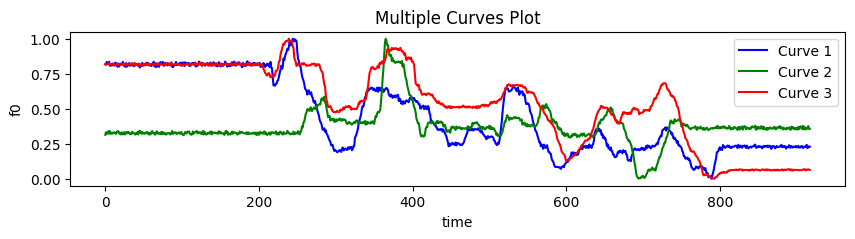

In [140]:
plot_curves(p0,p1,p2)

In [150]:
from model.eg import VAE
eg=VAE().cuda()
eg.load_state_dict(torch.load('./psg_mylossf_50.pt'))

<All keys matched successfully>

In [151]:
with torch.no_grad():
    noise = torch.randn(1, 64).cuda()
    generated_emb = eg.Decoder(noise)
generated_emb.shape

torch.Size([1, 256])

# embspeech

In [5]:
def get_sim(path1, path2):
    emb1=get_embed(path1)
    emb2=get_embed(path2)
    return cosine_similarity(emb1,emb2)

In [6]:
refs = '''/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/1188/133604/1188_133604_000023_000000.wav 10.789958333333333
/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/1995/1836/1995_1836_000004_000012.wav 11.57
/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/260/123286/260_123286_000034_000002.wav 10.96
/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/1284/1181/1284_1181_000003_000002.wav 10.77
/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/237/134500/237_134500_000009_000000.wav 10.18
/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/908/31957/908_31957_000003_000002.wav 13.66
/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/121/127105/121_127105_000044_000004.wav 17.06
/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/1089/134691/1089_134691_000003_000000.wav 10.73
/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/2961/961/2961_961_000016_000004.wav 13.680041666666666
/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/4077/13754/4077_13754_000003_000000.wav 11.17'''.split("\n")
refs

['/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/1188/133604/1188_133604_000023_000000.wav 10.789958333333333',
 '/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/1995/1836/1995_1836_000004_000012.wav 11.57',
 '/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/260/123286/260_123286_000034_000002.wav 10.96',
 '/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/1284/1181/1284_1181_000003_000002.wav 10.77',
 '/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/237/134500/237_134500_000009_000000.wav 10.18',
 '/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/908/31957/908_31957_000003_000002.wav 13.66',
 '/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/121/127105/121_127105_000044_000004.wav 17.06',
 '/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/1089/134691/1089_134691_000003_000000.wav 10.73',
 '/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/2961/961/2961_961_000016_000004.wav 13.680041666666666',
 '/home/huangf79/projects/Grad-TTS/LibriTTS/test-clea

In [7]:
def spk2ref(spk):
    for ref in refs:
        if ref.startswith(f'/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/{spk}/'):
            return ref.split()[0]
spk2ref('1188')

'/home/huangf79/projects/Grad-TTS/LibriTTS/test-clean/1188/133604/1188_133604_000023_000000.wav'

In [8]:
import numpy as np
from tqdm import tqdm

In [32]:
with open('/home/huangf79/projects/UnitSpeech/notebooks/src-tgt.txt', 'r') as ff:
    pairs = ff.readlines()
ss = []
for pair in tqdm(pairs):
    wavpath, refpath = pair.strip().split('|')[0], pair.strip().split('|')[1]
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:26<00:00,  3.75it/s]


(0.5892613, 0.07737064)

In [12]:
dir = 'es_vc'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = wavpath.split('_to_')[1].split('.')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:29<00:00,  3.41it/s]


(0.7588462, 0.0340766)

In [9]:
dir = 'es_vc-16k'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = wavpath.split('_to_')[1].split('.')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:07<00:00, 13.35it/s]


(0.75810695, 0.03477516)

In [13]:
dir = '/home/huangf79/projects/UnitSpeech/notebooks/uszs_vc'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = wavpath.split('_to_')[1].split('.')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:29<00:00,  3.40it/s]


(0.7366628, 0.06745279)

In [14]:
dir = '/home/huangf79/projects/UnitSpeech/notebooks/usft_vc'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = wavpath.split('_to_')[1].split('.')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:29<00:00,  3.40it/s]


(0.90961695, 0.031098044)

In [15]:
dir = '/home/huangf79/projects/UnitSpeech/yourtts_test/vc_zs'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = wavpath.split('_to_')[1].split('.')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:18<00:00,  5.30it/s]


(0.81336594, 0.036642518)

In [19]:
dir = 'es_tts_t2e'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:29<00:00,  3.41it/s]


(0.74501044, 0.049690206)

In [10]:
dir = 'es_tts_t2e-16k'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:07<00:00, 13.13it/s]


(0.7434141, 0.05001041)

In [20]:
dir = 'es_tts_t2e_75'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:29<00:00,  3.42it/s]


(0.7481798, 0.046272743)

In [21]:
dir = 'es_tts_t2e_50'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:29<00:00,  3.41it/s]


(0.7431704, 0.049043596)

In [22]:
dir = 'es_tts_t2e_25'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:29<00:00,  3.43it/s]


(0.7434185, 0.047217306)

In [11]:
dir = 'es_tts_t2e_05'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:18<00:00,  5.37it/s]


(0.7392485, 0.054953583)

In [27]:
dir = '/home/huangf79/projects/UnitSpeech/notebooks/uszs'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:28<00:00,  3.54it/s]


(0.69871956, 0.068281405)

In [28]:
dir = '/home/huangf79/projects/UnitSpeech/notebooks/usft'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:28<00:00,  3.56it/s]


(0.87176704, 0.0574776)

In [29]:
dir = '/home/huangf79/projects/UnitSpeech/yourtts_test/tts_zs'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:18<00:00,  5.38it/s]


(0.79287076, 0.047822792)

## re

In [9]:
dir = '/home/huangf79/projects/xe_test/vc_zs'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = wavpath.split('_to_')[1].split('.')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:07<00:00, 13.07it/s]


(0.69429994, 0.065649346)

In [11]:
dir = '/home/huangf79/projects/CosyVoice/cosy_test/vc_zs'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = wavpath.split('_to_')[1].split('.')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:18<00:00,  5.44it/s]


(0.919182, 0.020510716)

In [13]:
dir = '/home/huangf79/projects/FreeVC/freevcs_test_409'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = wavpath.split('_to_')[1].split('.')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:07<00:00, 13.44it/s]


(0.78994006, 0.06413317)

In [14]:
dir = '/home/huangf79/projects/DiffVC/diffvc_test'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = wavpath.split('_to_')[1].split('.')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:18<00:00,  5.46it/s]


(0.7382117, 0.05763301)

In [18]:
## tts

In [19]:
dir = '/home/huangf79/projects/xe_test/tts_zs'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:07<00:00, 13.56it/s]


(0.6522958, 0.085752174)

In [22]:
dir = '/home/huangf79/projects/CosyVoice/cosy_test/tts_zs'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = spk2ref(spk)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:17<00:00,  5.73it/s]


(0.91026855, 0.06972908)

In [23]:
dir = '/home/huangf79/projects/vits_test/lj'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = '/home/huangf79/projects/Grad-TTS/LJSpeech-1.1/wavs/LJ001-0001.wav'
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:30<00:00,  3.30it/s]


(0.86760104, 0.06313568)

In [24]:
dir = '/home/huangf79/projects/vits_test/vctk/p245'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = '/home/huangf79/projects/DiffVC/dataset/vctk/wavs/p245/p245_003.wav'
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:32<00:00,  3.07it/s]


(0.89269423, 0.042877406)

In [25]:
dir = '/home/huangf79/projects/vits_test/vctk/p270'
# ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = '/home/huangf79/projects/DiffVC/dataset/vctk/wavs/p270/p270_003.wav'
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss), len(ss)

100%|██████████| 100/100 [00:31<00:00,  3.22it/s]


(0.8617786, 0.05286992, 200)

In [35]:
dir = '/home/huangf79/projects/DiffVC/es_tts_t2e_lj_0'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = '/home/huangf79/projects/Grad-TTS/LJSpeech-1.1/wavs/LJ001-0001.wav'
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:29<00:00,  3.38it/s]


(0.641008, 0.05108897)

In [27]:
dir = '/home/huangf79/projects/DiffVC/es_tts_t2e_vctk/p245'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = '/home/huangf79/projects/DiffVC/dataset/vctk/wavs/p245/p245_003.wav'
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 100/100 [00:33<00:00,  2.96it/s]


(0.9122458, 0.042567726)

In [28]:
dir = '/home/huangf79/projects/DiffVC/es_tts_t2e_vctk/p270'
ss = []
for wavpath in tqdm(search_wavs(dir)):
    spk = os.path.basename(wavpath).split('_')[0]
    refpath = '/home/huangf79/projects/DiffVC/dataset/vctk/wavs/p270/p270_003.wav'
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss),len(ss)

100%|██████████| 100/100 [00:32<00:00,  3.05it/s]


(0.84119964, 0.045540195, 100)

## SSC

In [7]:
from tqdm import tqdm
import numpy as np

In [11]:
def path2ref(wavpath):
    filename = os.path.basename(wavpath).split('.')[0]
    dir = '/home/huangf79/projects/DISSC/results/vctk/orig'
    tgt = wavpath.split('/')[-2]
    utt = filename.split('_')[1]
    refpath = f'{dir}/{tgt}_{utt}.wav'
    return refpath

In [18]:
dir = 'es_u2e'
ss = []
wavpaths = search_wavs(dir)
wavpaths = [wavpath for wavpath in wavpaths if wavpath.split('/')[-2] != wavpath.split('/')[-1].split('_')[0]]
for wavpath in tqdm(wavpaths):
    refpath = path2ref(wavpath)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 120/120 [00:15<00:00,  7.75it/s]


(0.83100355, 0.060326517)

In [12]:
dir = 'es_u2e-16k'
ss = []
wavpaths = search_wavs(dir)
wavpaths = [wavpath for wavpath in wavpaths if wavpath.split('/')[-2] != wavpath.split('/')[-1].split('_')[0]]
for wavpath in tqdm(wavpaths):
    refpath = path2ref(wavpath)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 120/120 [00:05<00:00, 20.63it/s]


(0.83094126, 0.0602783)

In [19]:
dir = 'es_u2e-1'
ss = []
wavpaths = search_wavs(dir)
wavpaths = [wavpath for wavpath in wavpaths if wavpath.split('/')[-2] != wavpath.split('/')[-1].split('_')[0]]
for wavpath in tqdm(wavpaths):
    refpath = path2ref(wavpath)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 120/120 [00:15<00:00,  7.76it/s]


(0.8294738, 0.060576603)

In [20]:
dir = '/home/huangf79/projects/DISSC/results/vctk/dissc_b'
ss = []
wavpaths = search_wavs(dir)
wavpaths = [wavpath for wavpath in wavpaths if int(os.path.basename(wavpath).split('.')[0].split('_')[1])<=10]
wavpaths = [wavpath for wavpath in wavpaths if wavpath.split('/')[-2] != wavpath.split('/')[-1].split('_')[0]]
for wavpath in tqdm(wavpaths):
    refpath = path2ref(wavpath)
    ss.append(get_sim(wavpath, refpath))
np.mean(ss), np.std(ss)

100%|██████████| 120/120 [00:05<00:00, 22.56it/s]


(0.80504954, 0.07693325)

In [22]:
src_spk = ['p231', 'p239', 'p245', 'p270']
trgt_spk = ['p231', 'p239', 'p245', 'p270']
utts = ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']

In [23]:
dir = '/home/huangf79/projects/DISSC/results/vctk/orig'
ss = []
for tgt in trgt_spk:
    for src in src_spk:
        if src == tgt:
            # continue
            pass
        else:
            for utt in utts:
                srcpath = f'{dir}/{src}_{utt}.wav'
                tgtpath = f'{dir}/{tgt}_{utt}.wav'
                ss.append(get_sim(srcpath, tgtpath))
len(ss), np.mean(ss), np.std(ss)

(120, 0.5951645, 0.077496916)